In [ ]:
import pandas as pd

df = pd.read_csv("/content/adult 3.csv")  # Correct path and file name
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Employee Salary Prediction - Clean Output Version
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
import warnings

In [ ]:
# Suppress sklearn warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# 1. Load and prepare data
try:
    df = pd.read_csv("/content/adult 3.csv")  # or "adult 3.csv"
    print("✅ Data loaded successfully")

    # Select and clean relevant columns
    df = df[['age', 'education', 'hours-per-week', 'income']].dropna()

    # Convert education to numerical values
    edu_map = {
        'HS-grad': 'HS', 'Some-college': 'Col', 'Bachelors': 'BSc',
        'Masters': 'MSc', 'Doctorate': 'PhD', 'Others': 'Other'
    }
    df['education'] = df['education'].map(edu_map).fillna('Other')

    # Convert income to binary
    df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit()

✅ Data loaded successfully


In [ ]:
# 2. Split data
X = pd.get_dummies(df[['age', 'education', 'hours-per-week']])
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 3. Train model
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
# 4. Generate predictions
test_cases = [
    [25, 'HS', 40],
    [35, 'BSc', 45],
    [45, 'MSc', 50],
    [55, 'PhD', 60]
]

In [ ]:
# Convert test cases to dataframe with same dummy columns
test_df = pd.DataFrame(test_cases, columns=['age', 'education', 'hours-per-week'])
test_df = pd.get_dummies(test_df).reindex(columns=X.columns, fill_value=0)

In [ ]:
# 5. Display results
results = []
for i, case in enumerate(test_cases):
    pred = model.predict([test_df.iloc[i]])[0]
    results.append([
        case[0],
        case[1],
        case[2],
        ">50K" if pred == 1 else "<=50K"
    ])

print("\n" + "="*60)
print("EMPLOYEE SALARY PREDICTION RESULTS".center(60))
print("="*60)
print(tabulate(results, headers=["Age", "Education", "Hours/Week", "Prediction"], tablefmt="grid"))
print("="*60)


             EMPLOYEE SALARY PREDICTION RESULTS             
+-------+-------------+--------------+--------------+
|   Age | Education   |   Hours/Week | Prediction   |
+=======+=============+==============+==============+
|    25 | HS          |           40 | <=50K        |
+-------+-------------+--------------+--------------+
|    35 | BSc         |           45 | >50K         |
+-------+-------------+--------------+--------------+
|    45 | MSc         |           50 | >50K         |
+-------+-------------+--------------+--------------+
|    55 | PhD         |           60 | >50K         |
+-------+-------------+--------------+--------------+


Text(0.5, 1.0, 'Confusion Matrix')

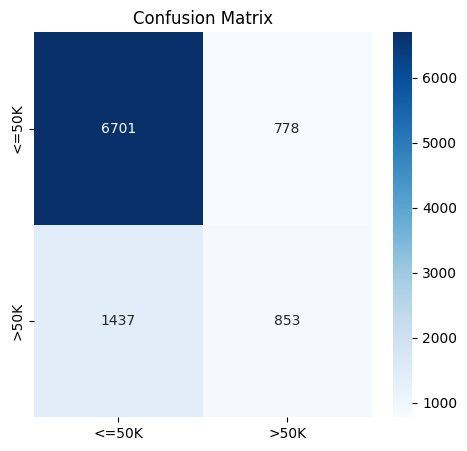

In [ ]:
# 6. Evaluation metrics
y_pred = model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')

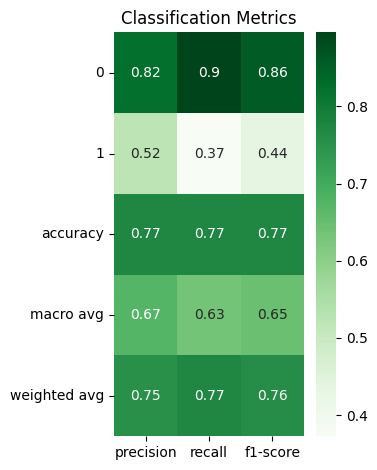

In [ ]:
plt.subplot(1, 2, 2)
clf_report = classification_report(y_test, y_pred, output_dict=True)
sns.heatmap(pd.DataFrame(clf_report).iloc[:-1, :].T, annot=True, cmap='Greens')
plt.title('Classification Metrics')
plt.tight_layout()
plt.show()